<a href="https://colab.research.google.com/github/rushinakhale115/NLP_Assignments/blob/main/NLP_Assignments/Ass_10_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.2 MB/s eta 0:00:00
✅ Libraries imported!


In [3]:
job_data = {
    'Job Title': [
        'Python Developer',
        'Data Scientist',
        'Machine Learning Engineer',
        'Web Developer',
        'Database Administrator',
        'DevOps Engineer',
        'Android Developer',
        'AI Research Scientist',
        'Frontend Developer',
        'Backend Developer',
        'Cloud Engineer',
        'Cybersecurity Analyst',
        'Data Analyst',
        'NLP Engineer',
        'Full Stack Developer'
    ],
    'Required Skills': [
        'python coding programming flask django rest api',
        'python data analysis statistics machine learning numpy pandas',
        'machine learning deep learning python tensorflow keras neural networks',
        'html css javascript react nodejs web design',
        'sql database mysql postgresql oracle data management',
        'docker kubernetes linux cloud deployment automation ci cd',
        'java android kotlin mobile app development xml',
        'artificial intelligence deep learning research python pytorch nlp',
        'html css javascript react ui ux design figma',
        'python java nodejs api rest database server programming',
        'aws azure cloud computing infrastructure devops linux',
        'network security firewall encryption linux cybersecurity hacking',
        'excel sql tableau data visualization statistics reporting',
        'nlp python text processing transformers bert language model',
        'html css javascript python react nodejs full stack web'
    ]
}

df = pd.DataFrame(job_data)
print("✅ Job dataset created!")
print(f"Total Jobs: {len(df)}\n")
print(df[['Job Title', 'Required Skills']].to_string(index=False))

✅ Job dataset created!
Total Jobs: 15

                Job Title                                                        Required Skills
         Python Developer                        python coding programming flask django rest api
           Data Scientist          python data analysis statistics machine learning numpy pandas
Machine Learning Engineer machine learning deep learning python tensorflow keras neural networks
            Web Developer                            html css javascript react nodejs web design
   Database Administrator                   sql database mysql postgresql oracle data management
          DevOps Engineer              docker kubernetes linux cloud deployment automation ci cd
        Android Developer                         java android kotlin mobile app development xml
    AI Research Scientist      artificial intelligence deep learning research python pytorch nlp
       Frontend Developer                           html css javascript react ui ux desi

In [4]:
tokenized_skills = [desc.lower().split() for desc in df['Required Skills']]

print("✅ Text tokenized!")
print(f"\nSample tokenized job skills:")
for i in range(3):
    print(f"  {df['Job Title'][i]}: {tokenized_skills[i]}")

✅ Text tokenized!

Sample tokenized job skills:
  Python Developer: ['python', 'coding', 'programming', 'flask', 'django', 'rest', 'api']
  Data Scientist: ['python', 'data', 'analysis', 'statistics', 'machine', 'learning', 'numpy', 'pandas']
  Machine Learning Engineer: ['machine', 'learning', 'deep', 'learning', 'python', 'tensorflow', 'keras', 'neural', 'networks']


In [5]:
w2v_model = Word2Vec(
    sentences   = tokenized_skills,
    vector_size = 50,       # embedding size
    window      = 5,        # context window
    min_count   = 1,        # include all words
    workers     = 4,
    epochs      = 200,
    sg          = 1         # Skip-gram
)

print("✅ Word2Vec model trained!")
print(f"Vocabulary size : {len(w2v_model.wv)}")
print(f"Embedding size  : {w2v_model.vector_size}")
print(f"\nSample word vectors (first 5 dims):")
for word in ['python', 'machine', 'html', 'sql', 'cloud']:
    vec = w2v_model.wv[word][:5]
    print(f"  {word:12}: {np.round(vec, 3)}")

✅ Word2Vec model trained!
Vocabulary size : 79
Embedding size  : 50

Sample word vectors (first 5 dims):
  python      : [ 0.042 -0.015 -0.154  0.066 -0.181]
  machine     : [ 0.025 -0.011 -0.112  0.025 -0.097]
  html        : [ 0.032 -0.014 -0.101  0.004 -0.108]
  sql         : [ 0.026 -0.038 -0.138  0.05  -0.136]
  cloud       : [ 0.049 -0.037 -0.119  0.081 -0.178]


In [6]:
def get_avg_vector(words, model):
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Create job vectors
job_vectors = np.array([
    get_avg_vector(skills, w2v_model)
    for skills in tokenized_skills
])

print("✅ Job vectors created!")
print(f"Job matrix shape: {job_vectors.shape}")
print(f"(15 jobs × {w2v_model.vector_size} dimensions)")

✅ Job vectors created!
Job matrix shape: (15, 50)
(15 jobs × 50 dimensions)


In [7]:
def recommend_jobs(user_skills, top_n=5):
    """
    Input : user skill string  e.g. "python machine learning data"
    Output: top N matching jobs with similarity scores
    """
    words      = user_skills.lower().split()
    user_vec   = get_avg_vector(words, w2v_model).reshape(1, -1)

    # Cosine similarity between user and all jobs
    similarities = cosine_similarity(user_vec, job_vectors)[0]

    # Get top N jobs
    top_indices = similarities.argsort()[::-1][:top_n]

    results = pd.DataFrame({
        'Rank'           : range(1, top_n + 1),
        'Job Title'      : df['Job Title'].iloc[top_indices].values,
        'Match Score (%)': (similarities[top_indices] * 100).round(2)
    })
    return results

print("✅ Recommendation function ready!")

✅ Recommendation function ready!


In [8]:
print("=" * 50)
print("   WORD SIMILARITY using Word2Vec")
print("=" * 50)

word_tests = ['python', 'machine', 'cloud', 'database', 'security']

for word in word_tests:
    similar = w2v_model.wv.most_similar(word, topn=3)
    similar_str = ', '.join([f"{w}({round(s,2)})" for w, s in similar])
    print(f"\n  '{word}' is similar to → {similar_str}")

print("\n" + "=" * 50)

   WORD SIMILARITY using Word2Vec

  'python' is similar to → learning(1.0), statistics(1.0), linux(1.0)

  'machine' is similar to → learning(0.99), python(0.99), data(0.99)

  'cloud' is similar to → automation(1.0), linux(1.0), deployment(0.99)

  'database' is similar to → python(0.99), mobile(0.99), learning(0.99)

  'security' is similar to → python(0.99), devops(0.99), cd(0.99)



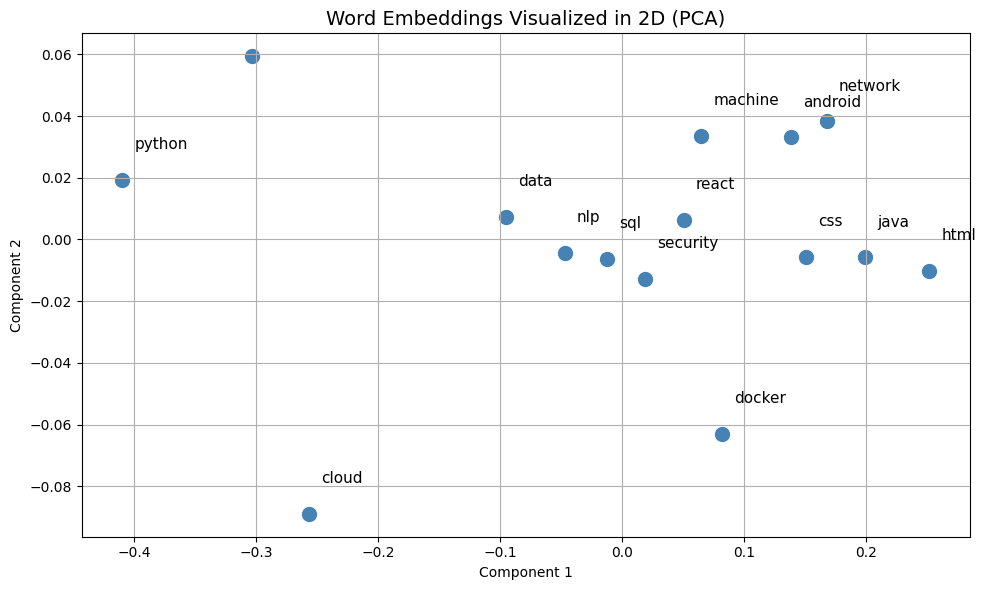

✅ Embedding plot shown!


In [9]:
keywords = ['python', 'java', 'html', 'css', 'sql', 'cloud',
            'machine', 'learning', 'security', 'android',
            'docker', 'react', 'data', 'network', 'nlp']

word_vecs = np.array([w2v_model.wv[w] for w in keywords if w in w2v_model.wv])
valid_words = [w for w in keywords if w in w2v_model.wv]

# Reduce to 2D
pca  = PCA(n_components=2)
coords = pca.fit_transform(word_vecs)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], color='steelblue', s=100)

for i, word in enumerate(valid_words):
    plt.annotate(word, (coords[i, 0] + 0.01, coords[i, 1] + 0.01), fontsize=11)

plt.title('Word Embeddings Visualized in 2D (PCA)', fontsize=14)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()
print("✅ Embedding plot shown!")

In [10]:
user_queries = [
    "python machine learning data",
    "html css javascript react",
    "sql database management",
    "docker cloud kubernetes linux",
    "android java mobile app",
    "deep learning neural network pytorch",
    "nlp text processing language model",
    "cybersecurity network firewall",
    "data visualization tableau excel",
    "nodejs api backend server",
    "aws azure cloud infrastructure",
    "python flask django rest api",
    "ui ux design figma frontend",
    "full stack web html python",
    "tensorflow keras deep learning python"
]

print("=" * 68)
print("   WORD EMBEDDING — JOB RECOMMENDATION SYSTEM (15 OUTPUTS)")
print("=" * 68)

for i, query in enumerate(user_queries, 1):
    result = recommend_jobs(query, top_n=1)
    job    = result['Job Title'].values[0]
    score  = result['Match Score (%)'].values[0]
    print(f"\n {i:2}. User Skills  : \"{query}\"")
    print(f"     Best Match  : {job}  |  Score: {score}%")

print("\n" + "=" * 68)
print("  Embedding Size  : 50 | Window: 5 | Algorithm: Skip-gram")
print("  Similarity Used : Cosine Similarity")
print(f"  Total Jobs      : {len(df)} | Vocab Size: {len(w2v_model.wv)}")
print("=" * 68)


   WORD EMBEDDING — JOB RECOMMENDATION SYSTEM (15 OUTPUTS)

  1. User Skills  : "python machine learning data"
     Best Match  : Data Scientist  |  Score: 99.97000122070312%

  2. User Skills  : "html css javascript react"
     Best Match  : Web Developer  |  Score: 99.94999694824219%

  3. User Skills  : "sql database management"
     Best Match  : Database Administrator  |  Score: 99.91999816894531%

  4. User Skills  : "docker cloud kubernetes linux"
     Best Match  : DevOps Engineer  |  Score: 99.95999908447266%

  5. User Skills  : "android java mobile app"
     Best Match  : Android Developer  |  Score: 99.95999908447266%

  6. User Skills  : "deep learning neural network pytorch"
     Best Match  : Machine Learning Engineer  |  Score: 99.91999816894531%

  7. User Skills  : "nlp text processing language model"
     Best Match  : NLP Engineer  |  Score: 99.97000122070312%

  8. User Skills  : "cybersecurity network firewall"
     Best Match  : Cybersecurity Analyst  |  Score: 9

In [11]:
print("=" * 55)
print("  DETAILED RECOMMENDATION — TOP 5 JOBS")
print("=" * 55)

user_input = "python data analysis machine learning statistics"
print(f"\n  User Skills: \"{user_input}\"\n")

top5 = recommend_jobs(user_input, top_n=5)
print(top5.to_string(index=False))
print("=" * 55)

  DETAILED RECOMMENDATION — TOP 5 JOBS

  User Skills: "python data analysis machine learning statistics"

 Rank                 Job Title  Match Score (%)
    1            Data Scientist        99.989998
    2 Machine Learning Engineer        99.919998
    3     AI Research Scientist        99.870003
    4              Data Analyst        99.860001
    5         Backend Developer        99.820000
